In [9]:
import torch
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from hydra import compose, initialize
from hydra.utils import instantiate
from scipy.stats import norm

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1]))

from maps_to_cosmology.encoder import Encoder
from maps_to_cosmology.datamodule import ConvergenceMapsModule

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Initialize the config:

In [10]:
with initialize(config_path="../configs", version_base=None):
    cfg = compose("train_npe_lsst_y10")

Instantiate the encoder using the checkpoint from a previous training run:

In [11]:
ckpt = "/data/scratch/blissWL_checkpoints/MVN_encoder_unstandardized.ckpt"
var_dist = instantiate(cfg.encoder.var_dist)
encoder = Encoder.load_from_checkpoint(
    ckpt,
    weights_only=False,
    var_dist=var_dist,
)
encoder.eval()
encoder.to(device)

Encoder(
  (train_rmse): RootMeanSquaredError()
  (train_pcc): PearsonCorrelationCoefficient()
  (val_rmse): RootMeanSquaredError()
  (val_scatter): ScatterPlot()
  (val_pcc): PearsonCorrelationCoefficient()
  (test_rmse): RootMeanSquaredError()
  (test_scatter): ScatterPlot()
  (test_pcc): PearsonCorrelationCoefficient()
  (net): ResNet(
    (stem): Sequential(
      (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
    )
    (layer1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (layer2): ResidualBlock(
      (conv1): Conv2d(32, 64, ke

Instantiate the test dataloader:

In [12]:
# this cell takes approximately 3 minutes
datamodule = ConvergenceMapsModule(
    data_dir=cfg.paths.data_dir,
    batch_size=cfg.convergence_maps.batch_size,
    num_workers=cfg.convergence_maps.num_workers,
    val_split=cfg.convergence_maps.val_split,
    test_split=cfg.convergence_maps.test_split,
    seed=cfg.seed,
    standardize_params=cfg.convergence_maps.standardize_params,
)
datamodule.setup()
test_loader = datamodule.test_dataloader()

Loading combined_batches.pt from /data/scratch/convergence_maps/lsst_y10_lognormal_with_noise
Loaded 99999 samples
Maps shape: torch.Size([99999, 256, 256, 5])
Params shape: torch.Size([99999, 6])
Train samples: 80001
Val samples: 9999
Test samples: 9999


Load in the convergence maps from the test set and evaluate the encoder on them. Also load the correspoding cosmological parameters from the test set:

In [13]:
# posterior_means = []
# posterior_stdevs = []
# true_params = []

# with torch.no_grad():
#     for maps, params in test_loader:
#         maps = maps.to(device)
        
#         out = encoder(maps)
#         posterior_mean = out[:, 0::2]
#         posterior_means.append(posterior_mean.cpu())
        
#         posterior_stdev = out[:, 1::2].clamp(-10, 10).exp().sqrt()
#         posterior_stdevs.append(posterior_stdev.cpu())
        
#         true_params.append(params)

# posterior_means = torch.cat(posterior_means, dim=0)
# posterior_stdevs = torch.cat(posterior_stdevs, dim=0)
# true_params = torch.cat(true_params, dim=0)

In [14]:
posterior_means = []
posterior_stdevs = []
true_params = []

with torch.no_grad():
    for maps, params in test_loader:
        maps = maps.to(device)
        out = encoder(maps)
        dist = encoder.var_dist.get_dist(out)
        posterior_mean = dist.loc
        posterior_std = torch.sqrt(
            torch.diagonal(dist.covariance_matrix, dim1=-2, dim2=-1)
        )
        posterior_means.append(posterior_mean.cpu())
        posterior_stdevs.append(posterior_std.cpu())
        true_params.append(params)

posterior_means = torch.cat(posterior_means, dim=0)
posterior_stdevs = torch.cat(posterior_stdevs, dim=0)
true_params = torch.cat(true_params, dim=0)

For each of the six cosmological parameters, create a scatterplot of the true parameter value versus the posterior mean. You'll want to use `plt.scatter()`. Arrange the six scatterplots in a 2x3 grid. How accurately do the posterior means approximate the true values? Explain why.

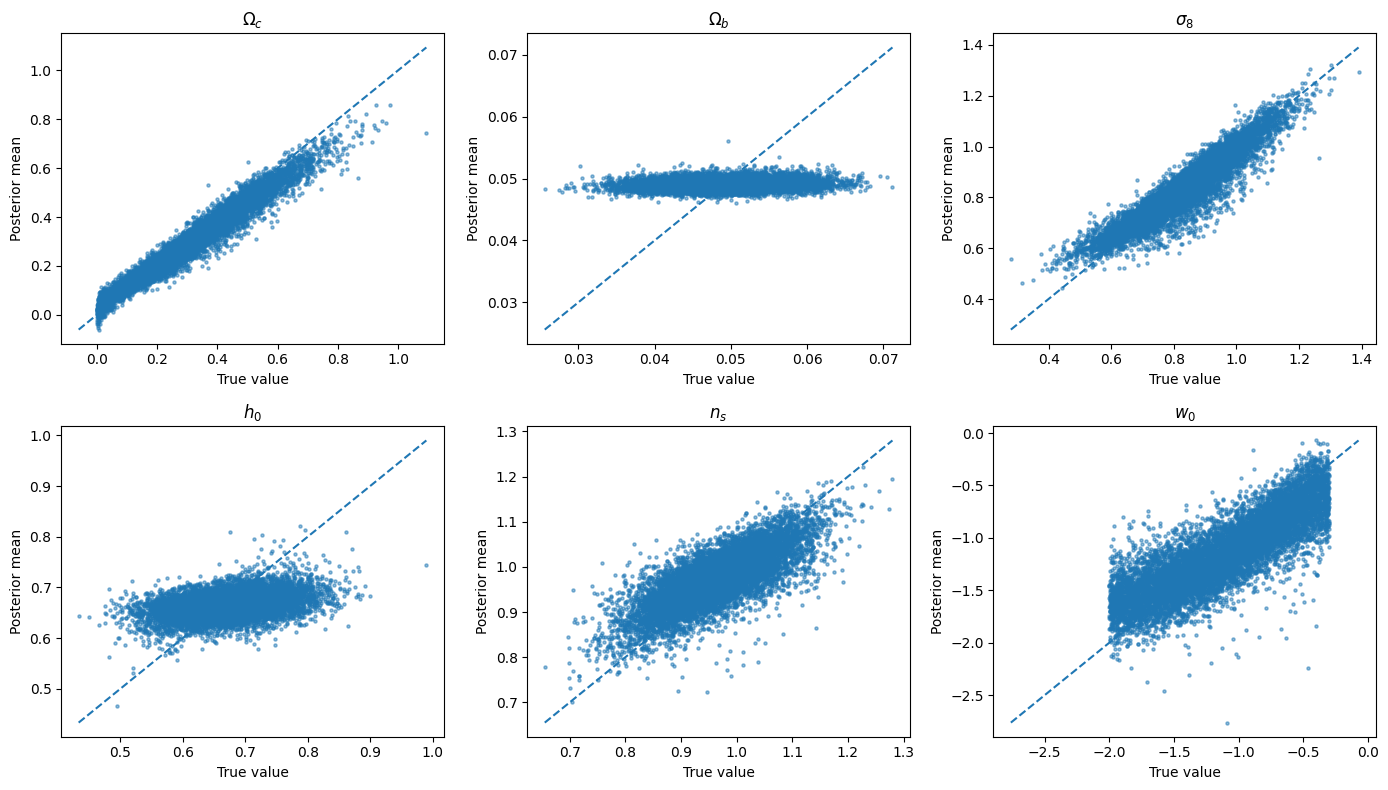

In [15]:
param_names = [
    r"$\Omega_c$", r"$\Omega_b$", r"$\sigma_8$",
    r"$h_0$", r"$n_s$", r"$w_0$"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]

    x = true_params[:, i].numpy()
    y = posterior_means[:, i].numpy()

    ax.scatter(x, y, s=5, alpha=0.5)
    minv = min(x.min(), y.min())
    maxv = max(x.max(), y.max())
    ax.plot([minv, maxv], [minv, maxv], linestyle="--")

    ax.set_xlabel("True value")
    ax.set_ylabel("Posterior mean")
    ax.set_title(param_names[i])

plt.tight_layout()
plt.show()

Observations:
- `Clumpiness of matter` $\sigma_8$ is the best constrained parameter.
- $\Omega_c$ shows positive correlation with the true value.
- $w_0$ shows **almost no correlation** with the truth. Weak lensing maps cannot constrain it well.
- $\Omega_b$, $h_0$, and $n_s$ shows weak correlation with the true value.

---

We load in the convergence map used as a reference map in this paper (https://arxiv.org/pdf/2409.17975):

In [16]:
reference_map = np.load("reference_map.npy")
reference_params = [0.2664, 0.0492, 0.831, 0.6727, 0.9645, -1.0]

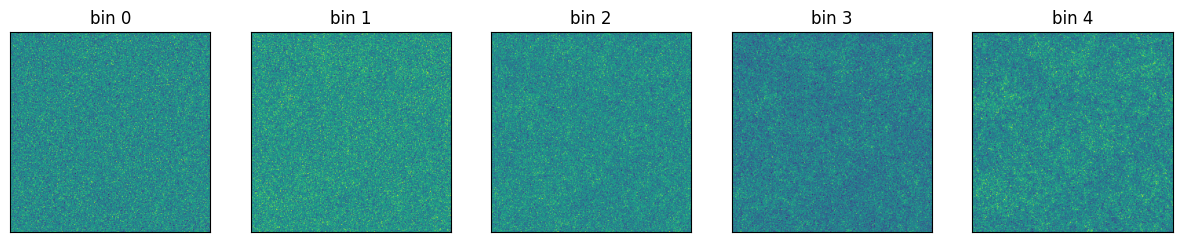

In [17]:
fig, ax = plt.subplots(1, 5, figsize = (15, 3))

for b in range(5):
    _ = ax[b].imshow(reference_map[...,b])
    _ = ax[b].set_title(f"bin {b}")
    _ = ax[b].set_xticks([])
    _ = ax[b].set_yticks([])

We plug this reference map into our trained encoder and plot the contours of the resulting variational distributions:

Write a function for the below cells, plugging in maps and true values as arguments as in Cell 10, create the contour plot as in Cell 11.

In [18]:
with torch.no_grad():
    reference_map_tensor = (
        torch.tensor(reference_map)
        .permute(2, 0, 1)          # [H,W,C] -> [C,H,W]
        .unsqueeze(0)              # -> [1,C,H,W]
        .to(device)
        .float()
    )
    out = encoder(reference_map_tensor)

    dist = encoder.var_dist.get_dist(out)

    posterior_mean = dist.loc.squeeze(0)
    posterior_stdev = torch.sqrt(
        torch.diagonal(dist.covariance_matrix, dim1=-2, dim2=-1)
    ).squeeze(0)

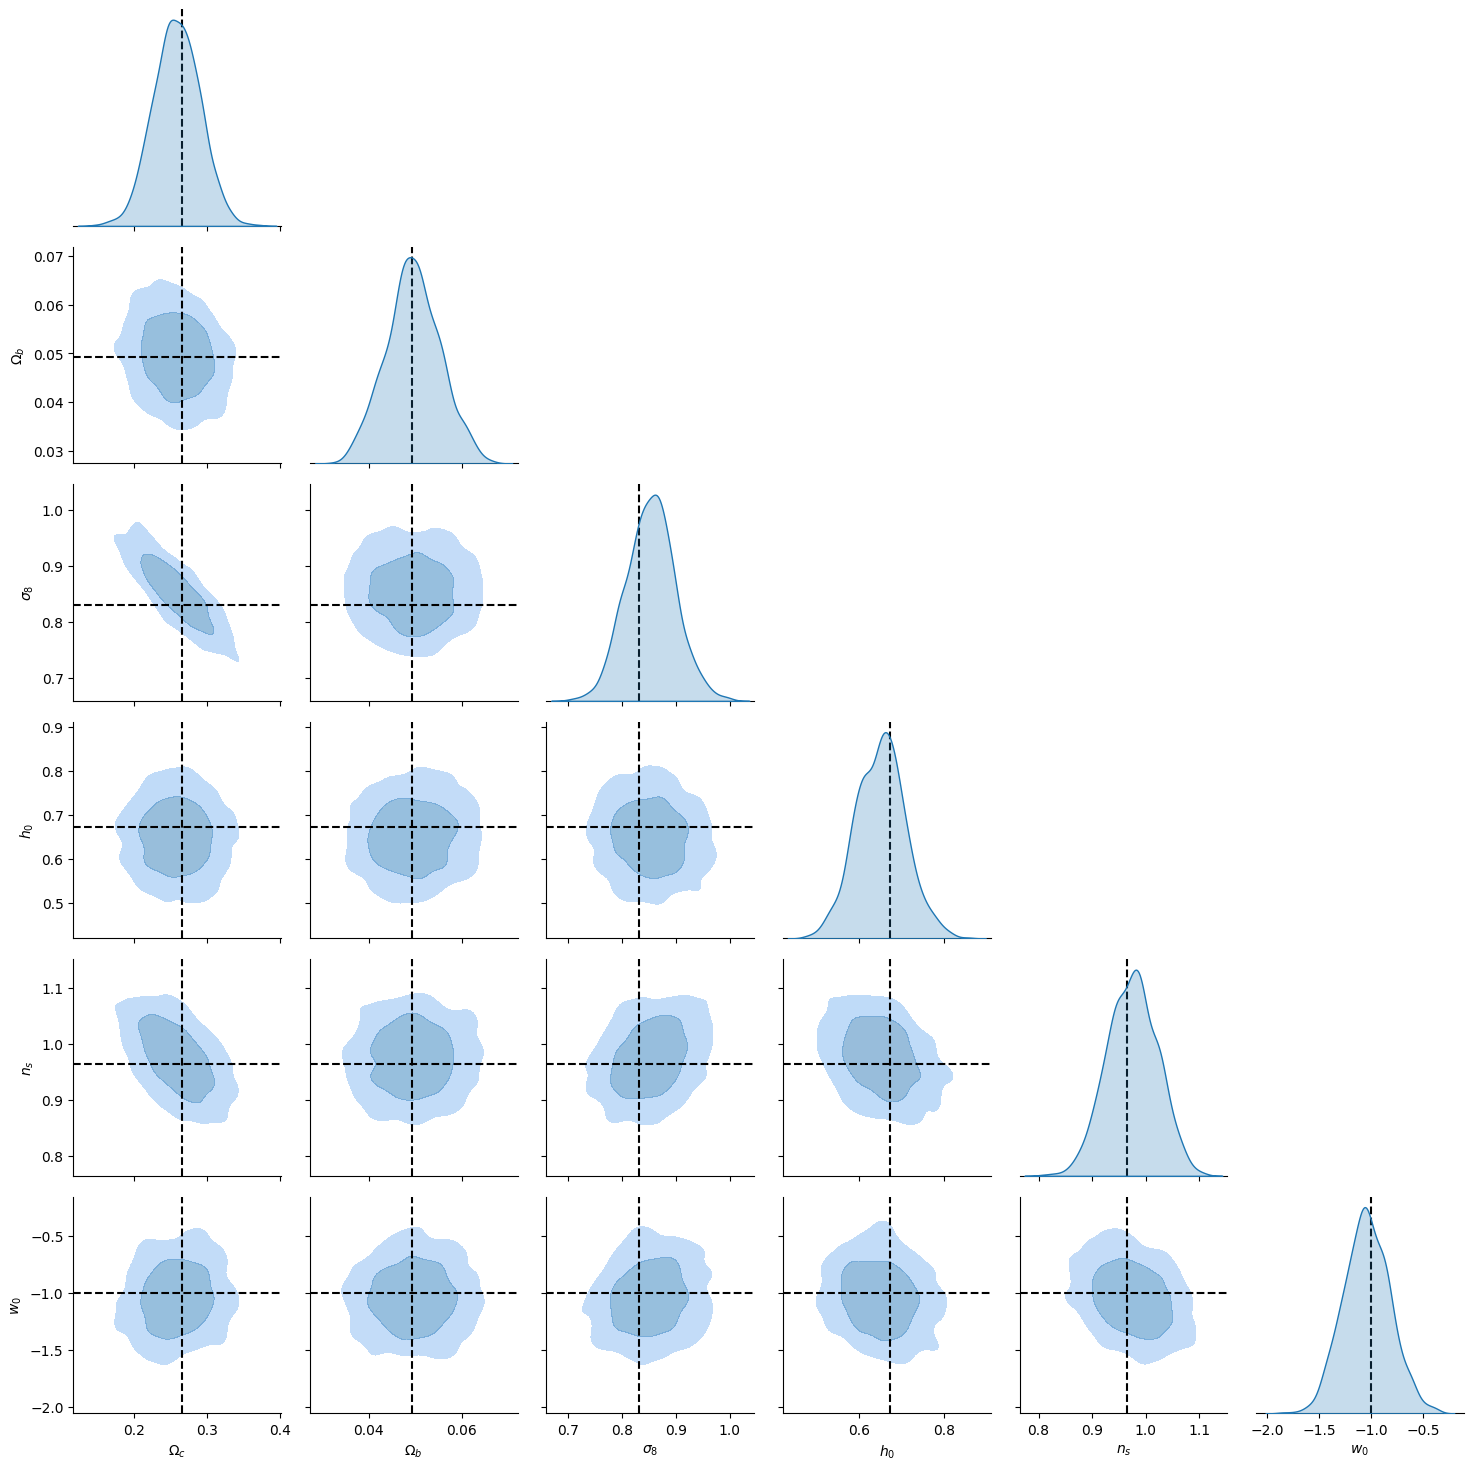

In [19]:
num_samples = 1000
samples = dist.rsample((num_samples,)).squeeze(1).cpu().numpy()
df = pd.DataFrame(samples, columns=param_names)

g = sns.PairGrid(df, corner=True, diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_lower(sns.kdeplot, levels=[0.05, 0.32, 1.0], fill=True, alpha=0.5)

for i in range(6):
    g.axes[i, i].axvline(reference_params[i], color="black", linestyle="--")
    for j in range(i):
        g.axes[i, j].axvline(reference_params[j], color="black", linestyle="--")
        g.axes[i, j].axhline(reference_params[i], color="black", linestyle="--")

In [20]:
def plot_posterior_contours_from_batch(
    encoder,
    maps,
    params,
    idx: int,
    param_names,
    device=None,
    num_samples: int = 1000,
    levels=(0.05, 0.32, 1.0),
    fill=True,
    alpha=0.5,
):
    """Generate the contour plot base on your inputs."""
    encoder.eval()
    x = maps[idx]
    y_true = params[idx]

    with torch.no_grad():
        if not torch.is_tensor(x):
            x = torch.tensor(x)
        if x.ndim != 3:
            raise ValueError(f"maps[idx] must be 3D, got {tuple(x.shape)}")

        if x.shape[-1] == 5 and x.shape[0] != 5:
            x = x.permute(2, 0, 1)
        x = x.unsqueeze(0).to(device).float()
        out = encoder(x)
        dist = encoder.var_dist.get_dist(out)

        posterior_mean = dist.loc.squeeze(0)
        posterior_stdev = torch.sqrt(
            torch.diagonal(dist.covariance_matrix, dim1=-2, dim2=-1)
        ).squeeze(0)
        samples = dist.rsample((num_samples,)).squeeze(1).cpu().numpy()

    df = pd.DataFrame(samples, columns=param_names)
    g = sns.PairGrid(df, corner=True, diag_sharey=False)
    g.map_diag(sns.kdeplot, fill=True)
    g.map_lower(sns.kdeplot, levels=list(levels), fill=fill, alpha=alpha)
    true_np = y_true.detach().cpu().numpy() if torch.is_tensor(y_true) else np.asarray(y_true)
    n = len(param_names)

    for i in range(n):
        g.axes[i, i].axvline(true_np[i], color="black", linestyle="--")
        for j in range(i):
            g.axes[i, j].axvline(true_np[j], color="black", linestyle="--")
            g.axes[i, j].axhline(true_np[i], color="black", linestyle="--")

    return dist, posterior_mean, posterior_stdev, g

In [21]:
maps, params = next(iter(test_loader))

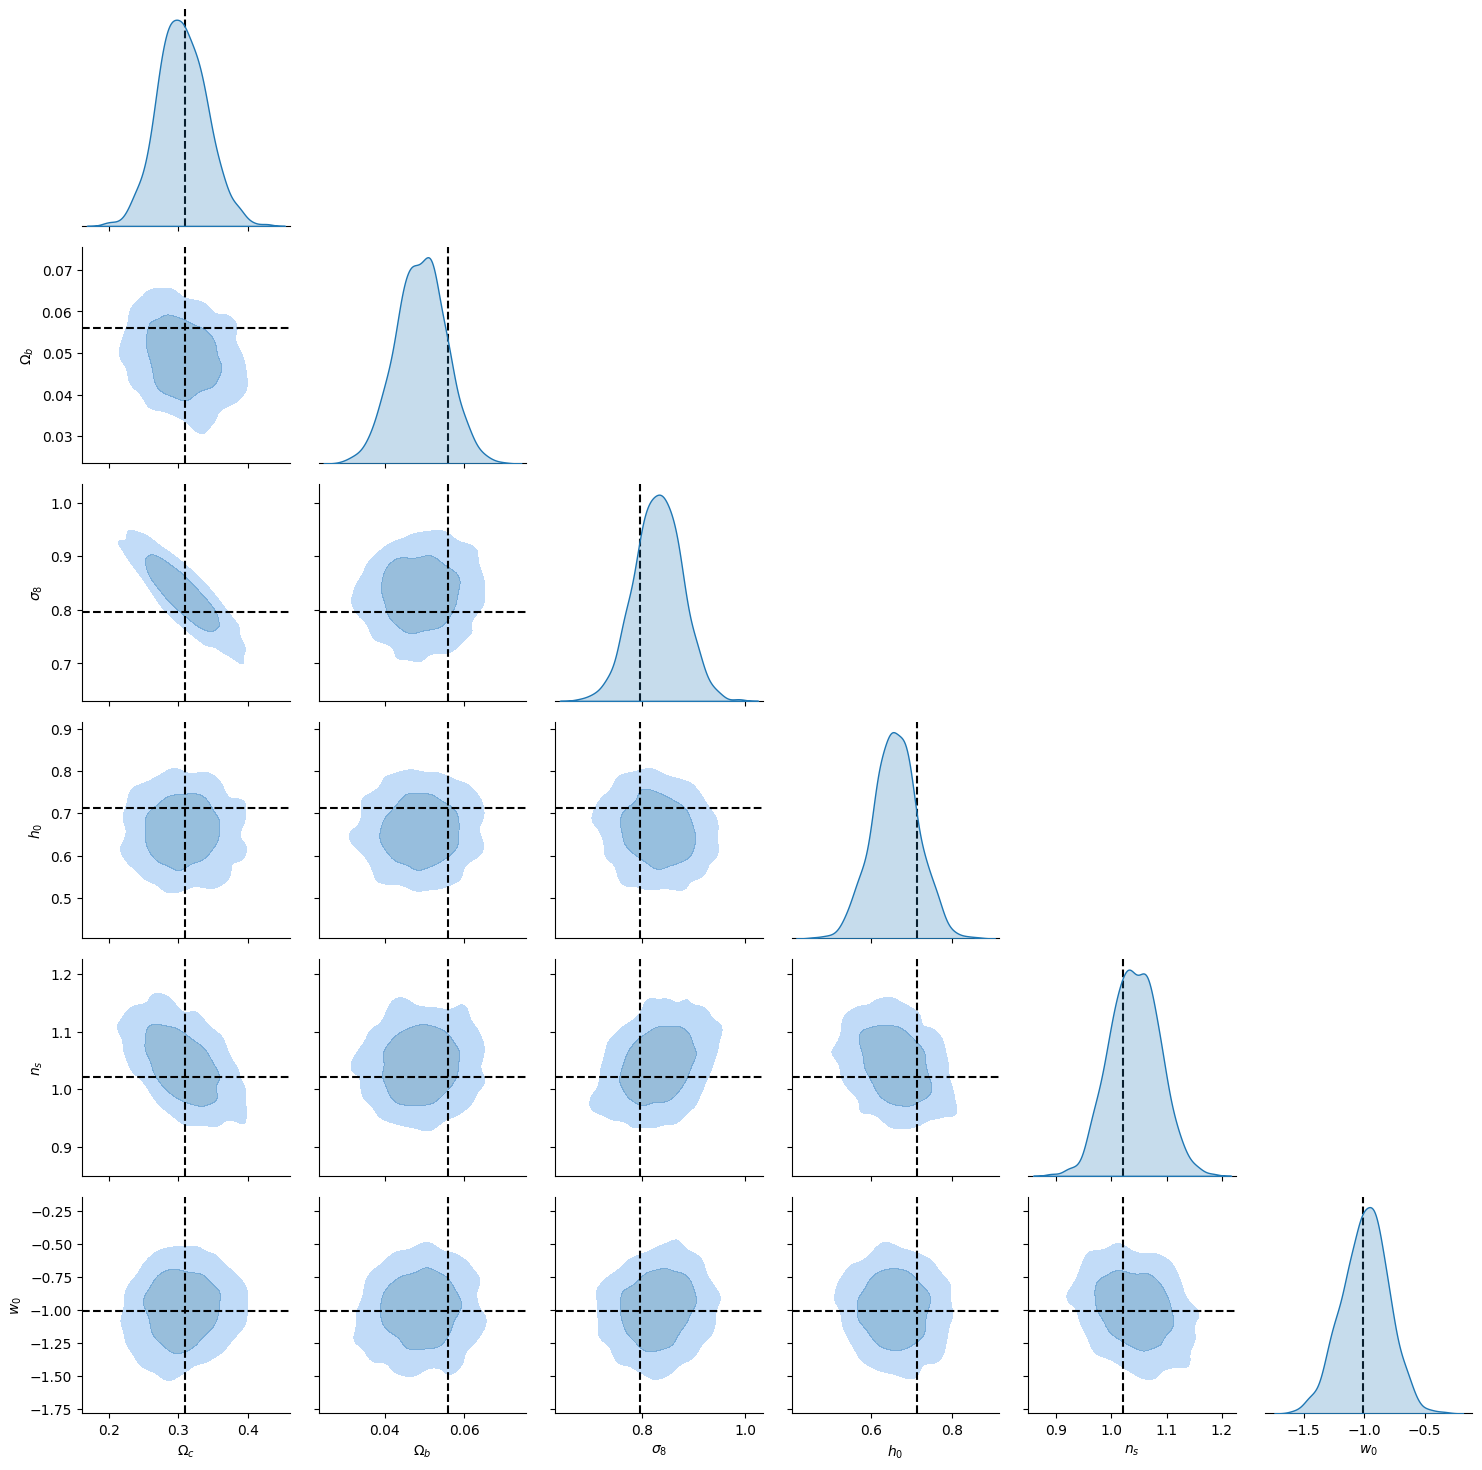

In [22]:
idx = 0         # [0,32)
dist, post_mu, post_sd, g = plot_posterior_contours_from_batch(
    encoder=encoder,
    maps=maps,
    params=params,
    idx=idx,
    param_names=param_names,
    device=device,
    num_samples=1000,
)

Plot credible intervals:

Credible Interval Level: 90%
$\Omega_c$: Coverage =  0.932
$\Omega_b$: Coverage =  0.930
$\sigma_8$: Coverage =  0.950
$h_0$: Coverage =  0.906
$n_s$: Coverage =  0.908
$w_0$: Coverage =  0.920


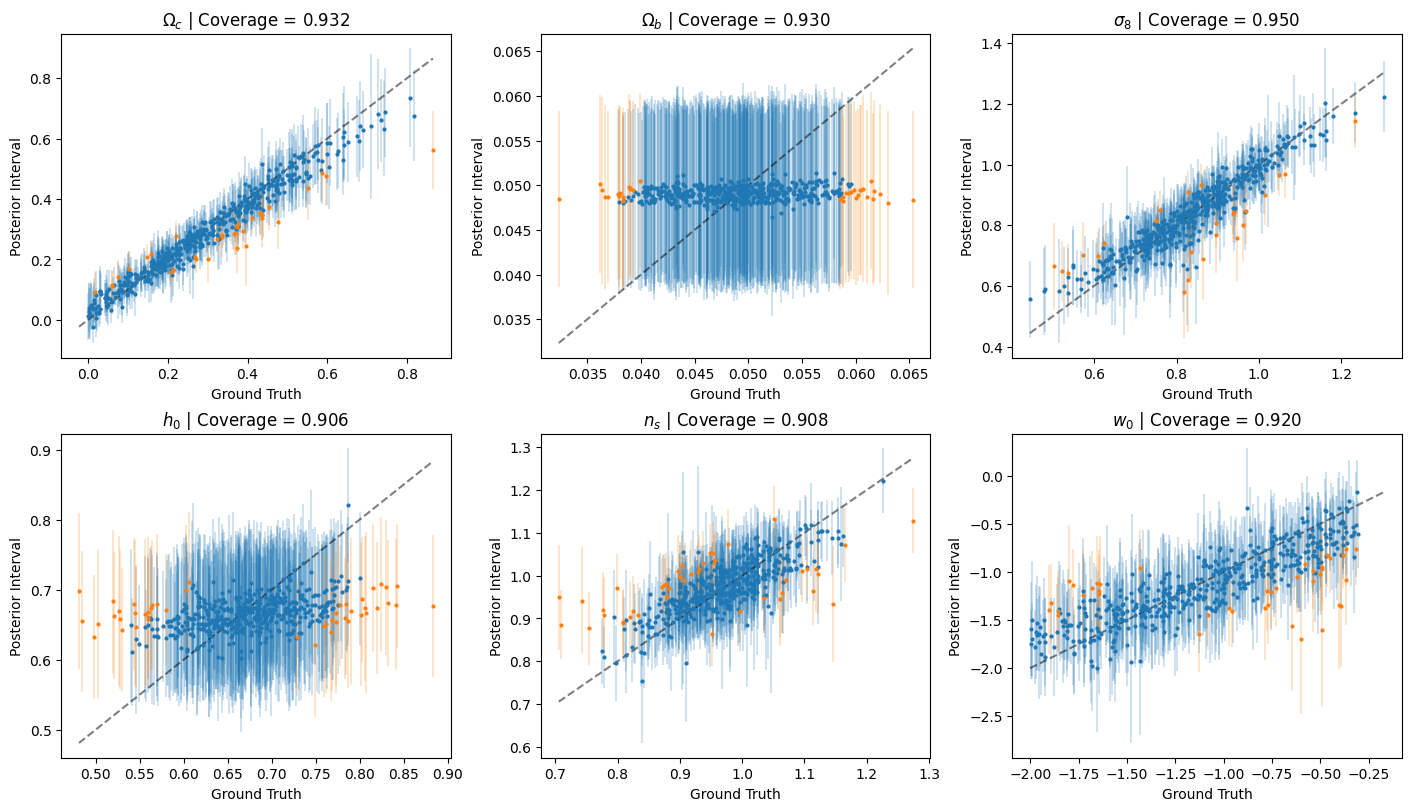

In [23]:
z = 1.645                 # 90% credible interval
n_plot = 500
rng = np.random.default_rng(42)

mu   = posterior_means.detach().cpu().numpy()     # [N,6]
sig  = posterior_stdevs.detach().cpu().numpy()    # [N,6]
true = true_params.detach().cpu().numpy()         # [N,6]

N = true.shape[0]
idx = rng.choice(N, size=min(n_plot, N), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

print(f"Credible Interval Level: 90%")
coverages = []
for j, name in enumerate(param_names):
    x = true[idx, j]
    y = mu[idx, j]
    yerr = z * sig[idx, j]
    lower = y - yerr
    upper = y + yerr
    covered = (x >= lower) & (x <= upper)
    cov = covered.mean()
    coverages.append(cov)
    print(f"{name}: Coverage = {cov: .3f}")

    ax = axes[j]
    ax.errorbar(
        x[covered], y[covered],
        yerr=yerr[covered],
        fmt="o",
        markersize=2,
        alpha=1,
        linewidth=0.3,
        capsize=0,
    )

    ax.errorbar(
        x[~covered], y[~covered],
        yerr=yerr[~covered],
        fmt="o",
        markersize=2,
        alpha=1,
        linewidth=0.3,
        capsize=0,
    )

    # y=x diagonal
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
    
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Posterior Interval")
    ax.set_title(f"{name} | Coverage = {coverages[j]:.3f}")

plt.show()


Empirical Coverage vs Nominal Coverage

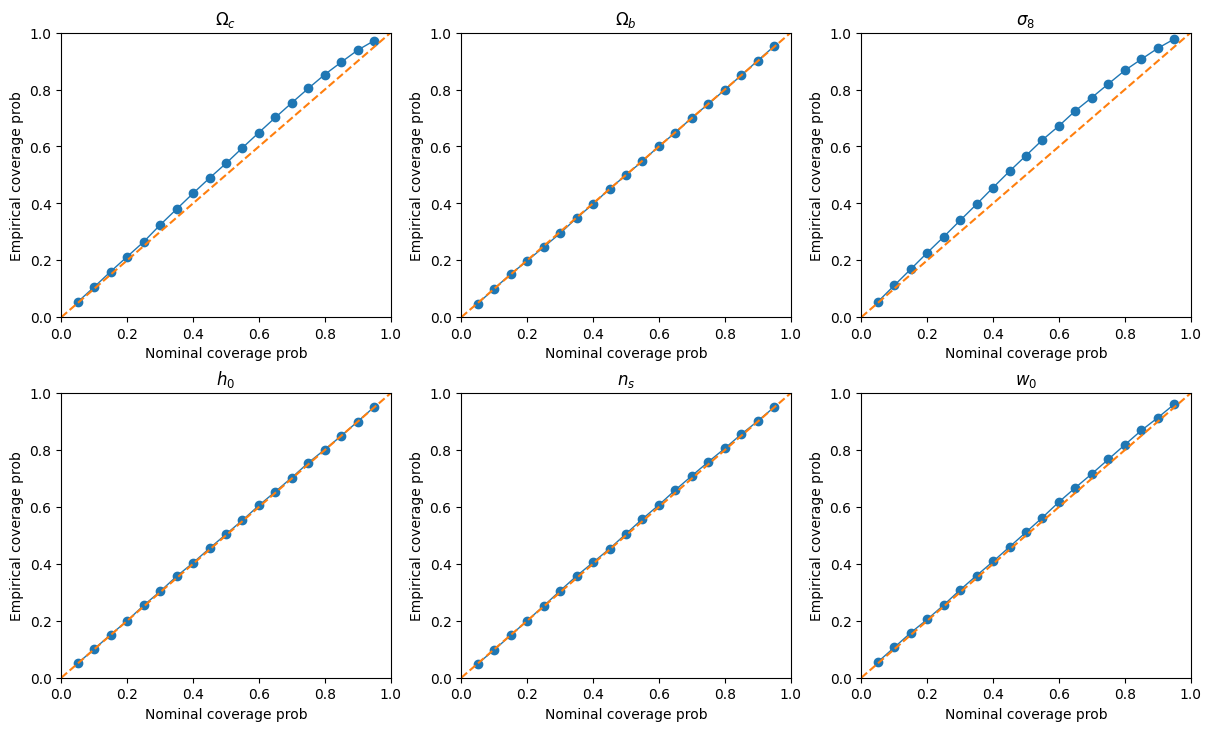

ECE per parameter:
  $\Omega_c$: 0.0332
  $\Omega_b$: 0.0016
  $\sigma_8$: 0.0487
  $h_0$: 0.0029
  $n_s$: 0.0048
  $w_0$: 0.0116


In [24]:
encoder.eval()

levels = np.linspace(0.05, 0.95, 19)
K = len(levels)
mus, sigmas, trues = [], [], []

with torch.no_grad():
    for maps, params in test_loader:
        maps = maps.to(device).float()
        params = params.to(device).float()

        out = encoder(maps)
        dist = encoder.var_dist.get_dist(out)

        mu = dist.loc
        var = torch.diagonal(dist.covariance_matrix, dim1=-2, dim2=-1)
        sigma = torch.sqrt(var)

        mus.append(mu.cpu())
        sigmas.append(sigma.cpu())
        trues.append(params.cpu())

mu = torch.cat(mus, dim=0).numpy()
sigma = torch.cat(sigmas, dim=0).numpy()
y_true = torch.cat(trues, dim=0).numpy()

N, d = y_true.shape
assert d == len(param_names)

emp = np.zeros((K, d), dtype=float)

for k, c in enumerate(levels):
    z = norm.ppf((1.0 + c) / 2.0)
    lo = mu - z * sigma
    hi = mu + z * sigma
    inside = (y_true >= lo) & (y_true <= hi)
    emp[k] = inside.mean(axis=0)

ncols = 3
nrows = int(np.ceil(d / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.6*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for j in range(d):
    ax = axes[j]
    ax.plot(levels, emp[:, j], marker="o", linewidth=1)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(param_names[j])
    ax.set_xlabel("Nominal coverage prob")
    ax.set_ylabel("Empirical coverage prob")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(d, len(axes)):
    axes[j].axis("off")

plt.show()
ece = np.mean(np.abs(emp - levels[:, None]), axis=0)
print("ECE per parameter:")
for name, val in zip(param_names, ece):
    print(f"  {name}: {val:.4f}")